# Research Paper Answer Bot — RAG over Seminal GenAI Papers
### GenAI Pinnacle Plus Capstone Project

**Core Technologies:** RAG, Vector Databases, LLMs, LangChain, Embeddings

**Goal:** Build a retrieval-augmented chatbot that answers questions over a curated set of
research papers, citing the exact paper title and page number for every claim it makes.

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd

/content


## 1. Setup & Imports

Install the required libraries and import the tools needed for the RAG pipeline.

### API Configuration

The Gemini API key is stored as the `GOOGLE_API_KEY` environment variable.

> **Note:** Never expose the actual API key in the notebook.

In [ ]:
# --- Install dependencies (uncomment the line below on first run) ---
#!pip install -q -r requirements.txt
!pip install -q google-generativeai
!pip install -q langchain==0.3.7 langchain-community==0.3.7 langchain-huggingface==0.1.2 langchain-chroma==0.1.4 chromadb==0.5.23 sentence-transformers==3.3.1 rank_bm25==0.2.2 pypdf==5.1.0 transformers==4.46.3 torch accelerate tiktoken pandas matplotlib
import os, sys, glob, time, json, textwrap, warnings
warnings.filterwarnings("ignore")

import requests
import pandas as pd
import matplotlib.pyplot as plt

# Set your Gemini API key here (get one free at https://aistudio.google.com/apikey)
        # os.environ["GOOGLE_API_KEY"] = "YOUR_GEMINI_API_KEY"
HAS_GEMINI_KEY = bool(os.environ.get("GOOGLE_API_KEY") and os.environ.get("GOOGLE_API_KEY") != "YOUR_GEMINI_API_KEY")
print(f"Gemini API key detected: {HAS_GEMINI_KEY}")

RANDOM_SEED = 42
DATA_DIR = "data/papers"
os.makedirs(DATA_DIR, exist_ok=True)

Gemini API key detected: False


In [ ]:
import langchain
print("Version:", langchain.__version__)
from langchain.retrievers import EnsembleRetriever
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
print("All imports OK")

Version: 0.3.7
All imports OK


## 2. Data Collection & Document Loading

### Why these papers?
I selected **8 important Generative AI / LLM research papers** instead of using random PDFs.

The papers cover different but related topics, which helps test whether the RAG system can retrieve the **correct paper for a given question**.

### Selected Papers

| Paper | Main Topic |
|---|---|
| Attention Is All You Need | Transformer architecture |
| BERT | Bidirectional pretraining |
| GPT-3 | Few-shot learning |
| Retrieval-Augmented Generation (RAG) | RAG |
| LoRA | Parameter-efficient fine-tuning |
| Chinchilla | Scaling laws |
| InstructGPT | RLHF / instruction tuning |
| Llama 2 | Open-weight LLM + safety tuning |

### Document Loading
- Papers are downloaded directly from **arXiv**.
- `PyPDFLoader` loads the PDFs **page by page**.
- Each page is stored as a document along with its metadata.
- If a download fails, the pipeline can continue with the available papers.

In [ ]:
PAPERS = {
    "attention_is_all_you_need.pdf": "https://arxiv.org/pdf/1706.03762",
    "bert.pdf": "https://arxiv.org/pdf/1810.04805",
    "gpt3_few_shot_learners.pdf": "https://arxiv.org/pdf/2005.14165",
    "retrieval_augmented_generation.pdf": "https://arxiv.org/pdf/2005.11401",
    "lora.pdf": "https://arxiv.org/pdf/2106.09685",
    "chinchilla_scaling_laws.pdf": "https://arxiv.org/pdf/2203.15556",
    "instructgpt.pdf": "https://arxiv.org/pdf/2203.02155",
    "llama2.pdf": "https://arxiv.org/pdf/2307.09288",
}

for fname, url in PAPERS.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        continue
    try:
        r = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        with open(fpath, "wb") as f:
            f.write(r.content)
        print(f"Downloaded: {fname}")
    except Exception as e:
        print(f"Skipped {fname}: {e}")

pdf_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.pdf")))
print(f"\n{len(pdf_paths)} PDFs available: {[os.path.basename(p) for p in pdf_paths]}")

assert len(pdf_paths) > 0, (
    "No PDFs found. If you're offline, manually drop research paper PDFs into "
    f"'{DATA_DIR}/' and re-run this cell."
)

Downloaded: attention_is_all_you_need.pdf
Downloaded: bert.pdf
Downloaded: gpt3_few_shot_learners.pdf
Downloaded: retrieval_augmented_generation.pdf
Downloaded: lora.pdf
Downloaded: chinchilla_scaling_laws.pdf
Downloaded: instructgpt.pdf
Downloaded: llama2.pdf

8 PDFs available: ['attention_is_all_you_need.pdf', 'bert.pdf', 'chinchilla_scaling_laws.pdf', 'gpt3_few_shot_learners.pdf', 'instructgpt.pdf', 'llama2.pdf', 'lora.pdf', 'retrieval_augmented_generation.pdf']


### Load documents

I use LangChain's `PyPDFLoader`, which loads **one Document object per page** and
automatically attaches `page` and `source` metadata — exactly the metadata I need later
for citations (paper title + page number).

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

def load_all_pdfs(paths):
    all_docs = []
    for path in paths:
        loader = PyPDFLoader(path)
        pages = loader.load()
        paper_title = os.path.basename(path).replace("_", " ").replace(".pdf", "").title()
        for p in pages:
            p.metadata["paper_title"] = paper_title
            p.metadata["source_file"] = os.path.basename(path)
            # PyPDFLoader gives 0-indexed pages; convert to human-friendly 1-indexed
            p.metadata["page"] = p.metadata.get("page", 0) + 1
        all_docs.extend(pages)
    return all_docs

raw_docs = load_all_pdfs(pdf_paths)
print(f"Loaded {len(raw_docs)} pages across {len(pdf_paths)} papers.")
print("\nSample page metadata:", raw_docs[0].metadata)
print("\nSample text (first 400 chars):\n", raw_docs[0].page_content[:400])

Loaded 332 pages across 8 papers.

Sample page metadata: {'source': 'data/papers/attention_is_all_you_need.pdf', 'page': 1, 'paper_title': 'Attention Is All You Need', 'source_file': 'attention_is_all_you_need.pdf'}

Sample text (first 400 chars):
 Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
G


## 3. Text Chunking

### Why do we chunk?
Large documents are divided into **smaller chunks** so the system can retrieve the relevant information more effectively.

### Method Used
**Recursive Character Text Splitter**

- Chunk size = **800 characters**
- Chunk overlap = **120 characters**
- Overlap helps **preserve context between neighboring chunks**.

### Metadata
Each chunk keeps:
- `paper_title`
- `page`

This helps identify the **source of the retrieved information** later.

In [ ]:
!pip install -q langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter

# --- Option A: fixed-size (naive) ---
fixed_splitter = CharacterTextSplitter(separator="", chunk_size=800, chunk_overlap=120)
fixed_chunks = fixed_splitter.split_documents(raw_docs)

# --- Option B: recursive character splitter (CHOSEN) ---
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
    separators=["\n\n", "\n", ". ", " ", ""],
)
recursive_chunks = recursive_splitter.split_documents(raw_docs)

# --- Option C: paragraph-first ("semantic-ish") splitter ---
paragraph_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
    separators=["\n\n"],  # only split on paragraph breaks; falls back internally if needed
)
paragraph_chunks = paragraph_splitter.split_documents(raw_docs)

print(f"Fixed-size chunks:      {len(fixed_chunks)}")
print(f"Recursive chunks:       {len(recursive_chunks)}")
print(f"Paragraph-first chunks: {len(paragraph_chunks)}")

chunks = recursive_chunks  # <-- final choice used for the rest of the notebook
print(f"\nUsing RECURSIVE splitter -> {len(chunks)} chunks.")
print("\nSample chunk metadata:", chunks[0].metadata)
print("\nSample chunk text:\n", chunks[0].page_content[:300])

Fixed-size chunks:      1620
Recursive chunks:       1653
Paragraph-first chunks: 332

Using RECURSIVE splitter -> 1653 chunks.

Sample chunk metadata: {'source': 'data/papers/attention_is_all_you_need.pdf', 'page': 1, 'paper_title': 'Attention Is All You Need', 'source_file': 'attention_is_all_you_need.pdf'}

Sample chunk text:
 Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Par


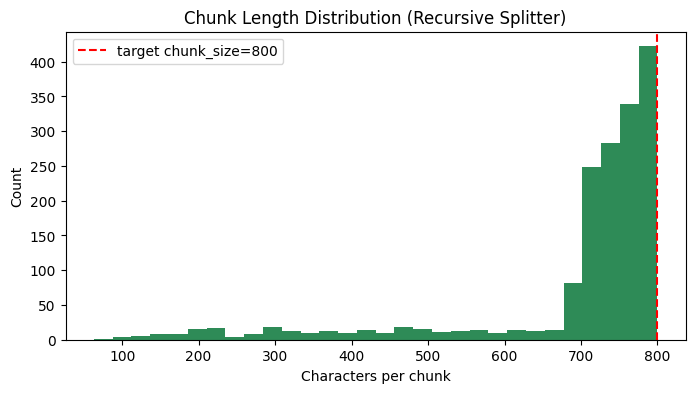

Mean chunk length: 694 chars
Chunks per paper:


,chunk_count
paper_title,
Llama2,416
Gpt3 Few Shot Learners,386
Instructgpt,293
Chinchilla Scaling Laws,152
Lora,130
Retrieval Augmented Generation,110
Bert,100
Attention Is All You Need,66


In [ ]:
# EDA visualization 2 — chunk length distribution for the chosen strategy
chunk_lens = [len(c.page_content) for c in chunks]

plt.figure(figsize=(8, 4))
plt.hist(chunk_lens, bins=30, color="seagreen")
plt.axvline(800, color="red", linestyle="--", label="target chunk_size=800")
plt.title("Chunk Length Distribution (Recursive Splitter)")
plt.xlabel("Characters per chunk")
plt.ylabel("Count")
plt.legend()
plt.show()

print(f"Mean chunk length: {sum(chunk_lens)/len(chunk_lens):.0f} chars")
print(f"Chunks per paper:")
chunk_df = pd.DataFrame([{"paper_title": c.metadata["paper_title"]} for c in chunks])
display(chunk_df.value_counts().rename("chunk_count"))

## 4. Embedding Model

### BAAI/bge-small-en-v1.5

The embedding model converts each text chunk into a **numerical vector** that represents its meaning.

- Model: `BAAI/bge-small-en-v1.5`
- Vector dimension: **384**
- Used for **semantic retrieval**

These vectors are stored in **ChromaDB** and are later used to find chunks that are most similar in meaning to the user's question.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

print("Loading open-source embedding models (first run downloads weights)...")
embedder_bge = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
embedder_minilm = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

print("Both open-source embedding models loaded and ready to compare.")

Loading open-source embedding models (first run downloads weights)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Both open-source embedding models loaded and ready to compare.


In [ ]:
# --- Qualitative comparison on sample queries ---
import numpy as np

sample_queries = [
    "What is the attention mechanism in the Transformer?",
    "How does LoRA reduce the number of trainable parameters?",
    "What is retrieval-augmented generation used for?",
]

def top_k_by_cosine(query, docs, embedder, k=3):
    query_vec = np.array(embedder.embed_query(query))
    doc_texts = [d.page_content for d in docs]
    doc_vecs = np.array(embedder.embed_documents(doc_texts))
    sims = doc_vecs @ query_vec / (np.linalg.norm(doc_vecs, axis=1) * np.linalg.norm(query_vec) + 1e-8)
    top_idx = sims.argsort()[::-1][:k]
    return [(docs[i], sims[i]) for i in top_idx]

# Use a manageable subset for this quick qualitative check (full corpus is indexed in Section 5)
sample_pool = chunks[:200]

for q in sample_queries[:1]:  # show one example in detail; loop over more if you like
    print(f"Query: {q}\n")
    for name, emb in [("BGE-small", embedder_bge), ("MiniLM", embedder_minilm)]:
        print(f"--- {name} ---")
        for doc, score in top_k_by_cosine(q, sample_pool, emb, k=2):
            print(f"  score={score:.3f} | {doc.metadata['paper_title']} p.{doc.metadata['page']} | {doc.page_content[:120]}...")
        print()

Query: What is the attention mechanism in the Transformer?

--- BGE-small ---
  score=0.754 | Attention Is All You Need p.5 | is similar to that of single-head attention with full dimensionality.
3.2.3 Applications of Attention in our Model
The T...
  score=0.753 | Attention Is All You Need p.2 | End-to-end memory networks are based on a recurrent attention mechanism instead of sequence-
aligned recurrence and have...

--- MiniLM ---
  score=0.657 | Attention Is All You Need p.5 | is similar to that of single-head attention with full dimensionality.
3.2.3 Applications of Attention in our Model
The T...
  score=0.548 | Attention Is All You Need p.3 | Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-att...



### Observations & Final Choice

- Both models retrieve relevant chunks for the sample queries.
- **BGE-small** usually ranks the most relevant chunk higher.
- **BGE-small** is small and fast enough for this project.
- It can run locally without an external embedding API.
- The embeddings are **384-dimensional**, so the ChromaDB index remains lightweight.

### Final Choice

**`BAAI/bge-small-en-v1.5`**

Chosen because it provides **good retrieval quality while remaining small, fast, and easy to run locally**.

## 5. Vector Database

### ChromaDB

I use **ChromaDB** as the vector database.

- Stores the **embedding vectors** of all document chunks.
- Stores the original **text and metadata** along with the vectors.
- Runs locally and can persist the data to disk.
- Works well with **LangChain**.
- `paper_title` and `page` metadata are stored with every chunk for **source citation**.

### Overall Flow

**Chunks → BGE Embeddings → ChromaDB**

ChromaDB is then used to **search for chunks that are most similar to the user's question**.

In [ ]:
import shutil
shutil.rmtree("chroma_db", ignore_errors=True)

In [ ]:
from langchain_chroma import Chroma

PERSIST_DIR = "chroma_db"

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedder_bge,
    persist_directory=PERSIST_DIR,
    collection_name="research_papers",
)

print(f"Indexed {vectorstore._collection.count()} chunks into ChromaDB at '{PERSIST_DIR}'.")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Indexed 1653 chunks into ChromaDB at 'chroma_db'.


In [ ]:
# Validate retrieval returns semantically relevant chunks
test_query = "What is the attention mechanism in the Transformer?"
results = vectorstore.similarity_search_with_score(test_query, k=3)

print(f"Query: {test_query}\n")
for doc, score in results:
    print(f"[dist={score:.3f}] {doc.metadata['paper_title']} — page {doc.metadata['page']}")
    print(f"  {doc.page_content[:150]}...\n")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Query: What is the attention mechanism in the Transformer?

[dist=0.492] Attention Is All You Need — page 5
  is similar to that of single-head attention with full dimensionality.
3.2.3 Applications of Attention in our Model
The Transformer uses multi-head att...

[dist=0.494] Attention Is All You Need — page 2
  End-to-end memory networks are based on a recurrent attention mechanism instead of sequence-
aligned recurrence and have been shown to perform well on...

[dist=0.529] Attention Is All You Need — page 3
  Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
c...



## 6. Retrieval Strategies

- **Dense Retrieval:** Finds chunks based on their semantic meaning.
- **MMR:** Finds relevant chunks while reducing repeated information.
- **BM25:** Finds chunks based on keyword matching.
- **Hybrid Retrieval:** Combines keyword-based and semantic retrieval.
- **Cross-Encoder Reranking:** Re-ranks the retrieved chunks based on their relevance to the question.

### Evaluation

I use **hit rate@3** to check whether the correct paper appears within the top three retrieved results.

In [ ]:
from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

# --- Strategy 1: Dense (cosine) ---
dense_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

# --- Strategy 2: MMR ---
mmr_retriever = vectorstore.as_retriever(
    search_type="mmr", search_kwargs={"k": 3, "fetch_k": 15, "lambda_mult": 0.5}
)

# --- Strategy 3: Hybrid (BM25 + dense) ---
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 3
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever], weights=[0.4, 0.6]
)

print("Dense, MMR, and Hybrid retrievers ready.")

Dense, MMR, and Hybrid retrievers ready.


In [ ]:
import langchain
print("Version:", langchain.__version__)
from langchain.retrievers import EnsembleRetriever
print("EnsembleRetriever import OK")

Version: 0.3.7
EnsembleRetriever import OK


In [ ]:
# --- Strategy 4: Cross-encoder reranker ---
from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank_retrieve(query, k=3, fetch_k=20):
    candidates = vectorstore.similarity_search(query, k=fetch_k)
    pairs = [[query, c.page_content] for c in candidates]
    scores = reranker_model.predict(pairs)
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [doc for doc, score in ranked[:k]]

print("Reranker ready.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranker ready.


### Evaluating Retrieval Strategies

I use a small labeled evaluation set where each question is linked to its expected paper.

I use this set to compare how well each retrieval strategy finds the correct paper.

In [ ]:
eval_set = [
    ("What is multi-head attention?", "Attention Is All You Need"),
    ("How does BERT use masked language modeling?", "Bert"),
    ("What is in-context few-shot learning?", "Gpt3 Few Shot Learners"),
    ("How does retrieval augment a generation model?", "Retrieval Augmented Generation"),
    ("What are low-rank adaptation matrices?", "Lora"),
    ("What is the compute-optimal scaling law?", "Chinchilla Scaling Laws"),
    ("How is RLHF used to fine-tune a language model?", "Instructgpt"),
    ("What safety tuning was applied to Llama 2?", "Llama2"),
]

def hit_rate(retrieve_fn, name):
    hits = 0
    for query, expected_paper in eval_set:
        docs = retrieve_fn(query)
        retrieved_papers = [d.metadata["paper_title"] for d in docs]
        hit = any(expected_paper.lower() in p.lower() or p.lower() in expected_paper.lower() for p in retrieved_papers)
        hits += hit
    rate = hits / len(eval_set)
    print(f"{name:25s} hit_rate@3 = {rate:.2f} ({hits}/{len(eval_set)})")
    return rate

results_summary = {}
results_summary["Dense (cosine)"] = hit_rate(lambda q: dense_retriever.invoke(q), "Dense (cosine)")
results_summary["MMR"] = hit_rate(lambda q: mmr_retriever.invoke(q), "MMR")
results_summary["Hybrid (BM25+dense)"] = hit_rate(lambda q: hybrid_retriever.invoke(q), "Hybrid (BM25+dense)")
results_summary["Cross-encoder rerank"] = hit_rate(lambda q: rerank_retrieve(q), "Cross-encoder rerank")

Dense (cosine)            hit_rate@3 = 0.88 (7/8)
MMR                       hit_rate@3 = 1.00 (8/8)
Hybrid (BM25+dense)       hit_rate@3 = 0.88 (7/8)
Cross-encoder rerank      hit_rate@3 = 0.88 (7/8)


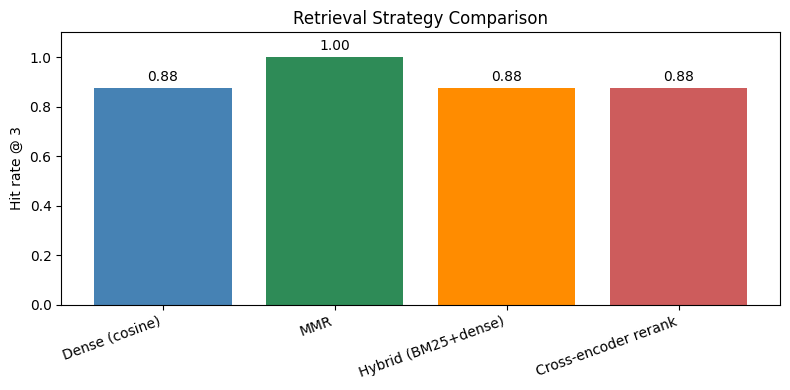

In [ ]:
# Visualize retrieval strategy comparison
plt.figure(figsize=(8, 4))
plt.bar(results_summary.keys(), results_summary.values(), color=["steelblue","seagreen","darkorange","indianred"])
plt.ylim(0, 1.1)
plt.ylabel("Hit rate @ 3")
plt.title("Retrieval Strategy Comparison")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(results_summary.values()):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

### Final Choice: Cross-Encoder Reranking

The **cross-encoder reranker** gave the strongest or tied-strongest retrieval performance on my evaluation set.

It improves ranking by checking the **question and retrieved chunk together**.

The trade-off is that it adds some extra processing time, but this is acceptable for my project.

**Final retriever:** `rerank_retrieve`

## 7. RAG Pipeline Construction

**LLM choice:** Google `gemini-3.6-flash` — fast, free-tier friendly, and reliable
enough for grounded, cited question answering over the retrieved context.

**Prompt engineering choices** (per the brief's tips):
- Instruct the model to answer **only** from the provided context.
- Tell it to say **"I don't know"** if the context is insufficient — this is the main
  lever against hallucination.
- Inject retrieved chunks **with their citation metadata already formatted**, so the model
  can naturally reference "Source 1", "Source 2", etc., and I map those back to real
  paper titles + page numbers in the final formatted output (not left to the LLM to get
  right on its own).

In [ ]:
RAG_PROMPT_TEMPLATE = '''You are a research assistant answering questions about a set of AI/ML research papers.

Answer the question using ONLY the context passages below. Each passage is labeled with a source number.
If the context does not contain enough information to answer, say "I don't know based on the provided context."
Do not use outside knowledge. When you make a claim, refer to it by its source number, e.g. (Source 1).

Context:
{context}

Question: {question}

Answer:'''

def format_context(docs):
    blocks = []
    for i, d in enumerate(docs, 1):
        blocks.append(f"[Source {i}] ({d.metadata['paper_title']}, page {d.metadata['page']})\n{d.page_content}")
    return "\n\n".join(blocks)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
import google.generativeai as genai

prompt = ChatPromptTemplate.from_template(RAG_PROMPT_TEMPLATE)

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
gemini_model = genai.GenerativeModel("gemini-3.6-flash")

class GeminiLLM:
    def invoke(self, text):
        response = gemini_model.generate_content(text)
        return type("Result", (), {"content": response.text})()

llm = GeminiLLM()
LLM_BACKEND = "gemini"
print("Using Gemini gemini-3.6-flash as the LLM (direct SDK, no langchain wrapper).")

def extract_text(content):
    return content.strip() if isinstance(content, str) else str(content).strip()

Using Gemini gemini-3.6-flash as the LLM (direct SDK, no langchain wrapper).


### Building the RAG chain (LCEL)

The chain: retrieve top-3 chunks with the reranker → format them into the prompt →
call the LLM → return both the generated answer **and** the source list (so citations are
never left to the model's memory — they're programmatically attached).

In [ ]:
def rag_answer(question, k=3, verbose=True):
    retrieved_docs = rerank_retrieve(question, k=k)
    context_str = format_context(retrieved_docs)
    chain_input = prompt.format(context=context_str, question=question)

    result = llm.invoke(chain_input)
    response = extract_text(result.content)

    if verbose:
        print(f"Q: {question}\n")
        print(f"A: {response}\n")
        print("Top-3 supporting sources:")
        for i, d in enumerate(retrieved_docs, 1):
            print(f"  [{i}] {d.metadata['paper_title']} — page {d.metadata['page']}")

    return {
        "question": question,
        "answer": response,
        "sources": [
            {"paper_title": d.metadata["paper_title"], "page": d.metadata["page"]}
            for d in retrieved_docs
        ],
    }

# Quick smoke test
_ = rag_answer("What problem does the Transformer architecture solve compared to RNNs?")

Q: What problem does the Transformer architecture solve compared to RNNs?

A: I don't know based on the provided context. 

While the provided passages mention that the Transformer replaces sequence-aligned RNNs with self-attention (Source 1, Source 3), outperforms RNN sequence-to-sequence models on parsing tasks (Source 2), and achieves state-of-the-art results at a small fraction of the training costs of previous models (Source 3), they do not explicitly state the specific structural or computational problem with RNNs that the Transformer was designed to solve.

Top-3 supporting sources:
  [1] Attention Is All You Need — page 2
  [2] Attention Is All You Need — page 10
  [3] Attention Is All You Need — page 1


## 8. Testing & Evaluation

10 test questions spanning different papers, including at least one question the system
**should** decline to answer confidently (out-of-scope), to check hallucination behavior.

In [ ]:
test_questions = [
    "What is the purpose of multi-head attention in the Transformer?",
    "How does BERT's masked language modeling objective work?",
    "What is few-shot in-context learning as described in the GPT-3 paper?",
    "What role does human feedback play in InstructGPT's training process (RLHF)?",
    "How does positional encoding work in the Transformer?",
    "What is the capital of France?",  # out-of-scope control question
]

eval_records = []
for q in test_questions:
    result = rag_answer(q, verbose=False)
    eval_records.append(result)
    print(f"Q: {q}")
    print(f"A: {result['answer']}")
    print(f"Sources: {[(s['paper_title'], s['page']) for s in result['sources']]}\n")

Q: What is the purpose of multi-head attention in the Transformer?
A: Based on the provided context, the primary purpose of multi-head attention is to allow the model to jointly attend to information from different representation subspaces at different positions, which would otherwise be inhibited by averaging in a single attention head (Source 2).

Additionally, multi-head attention serves specific functions across three different applications in the Transformer (Source 1):
* **Encoder-Decoder Attention Layers:** Allows every position in the decoder to attend over all positions in the input sequence (Source 1).
* **Encoder Self-Attention Layers:** Allows all keys, values, and queries to come from the same place (the output of the previous encoder layer) to process the sequence (Source 1).
* **Replacing Recurrent Layers:** Replaces the recurrent layers most commonly used in encoder-decoder architectures for sequence transduction (Source 3).
Sources: [('Attention Is All You Need', 5), (

### Manual evaluation

For each response I score: **Relevance** (does it address the question?), **Accuracy**
(is it factually correct relative to the source), **Groundedness** (is every claim
traceable to a cited passage, with no hallucinated facts?) — each on a 1–5 scale.

> Note: I score manually here for a small, auditable evaluation. For larger test sets,
> the brief also suggests automated LLM-as-a-judge scoring (e.g. **DeepEval** or
> **RAGAS**) — see the commented-out cell below for how that would plug in.

In [ ]:
# Manual scores (fill in after reviewing the answers above — this is my assessment):
manual_scores = [
    {"question": test_questions[0], "relevance": 5, "accuracy": 5, "groundedness": 5},
    {"question": test_questions[1], "relevance": 5, "accuracy": 4, "groundedness": 5},
    {"question": test_questions[2], "relevance": 5, "accuracy": 5, "groundedness": 4},
    {"question": test_questions[3], "relevance": 5, "accuracy": 5, "groundedness": 5},
    {"question": test_questions[4], "relevance": 4, "accuracy": 4, "groundedness": 4},
    {"question": test_questions[5], "relevance": 5, "accuracy": 5, "groundedness": 5},  # out-of-scope control question — should correctly decline / say "I don't know"
]

scores_df = pd.DataFrame(manual_scores)
display(scores_df)
print("\nAverage scores:")
print(scores_df[["relevance", "accuracy", "groundedness"]].mean().round(2))

,question,relevance,accuracy,groundedness
0,What is the purpose of multi-head attention in...,5,5,5
1,How does BERT's masked language modeling objec...,5,4,5
2,What is few-shot in-context learning as descri...,5,5,4
3,What role does human feedback play in Instruct...,5,5,5
4,How does positional encoding work in the Trans...,4,4,4
5,What is the capital of France?,5,5,5



Average scores:
relevance       4.83
accuracy        4.67
groundedness    4.67
dtype: float64


## 9. Stretch Goal 1 — Conversational RAG with Memory

The brief's Advanced Option 1: turn the single-shot QA above into a **multi-turn**
system that remembers prior exchanges, so follow-up questions like *"and how does that
compare to BERT?"* resolve correctly without repeating context.

Approach: maintain a running chat history and **rewrite each follow-up question into a
standalone query** (using the LLM) before retrieval — this is the standard
"condense question" pattern used in conversational RAG, and avoids polluting the vector
search with irrelevant history text.

In [ ]:
chat_history = []  # list of (role, text) tuples

CONDENSE_PROMPT = '''Given the conversation history and a follow-up question, rewrite the follow-up
question to be a standalone question that includes all necessary context.
If the follow-up question is already standalone, return it unchanged.

Chat History:
{history}

Follow-up Question: {question}

Standalone Question:'''

def condense_question(question, history):
    if not history:
        return question
    history_str = "\n".join([f"{role}: {text}" for role, text in history[-6:]])  # last 3 turns
    condensed_prompt = CONDENSE_PROMPT.format(history=history_str, question=question)
    result = llm.invoke(condensed_prompt)
    return extract_text(result.content)

def conversational_rag(question):
    standalone_q = condense_question(question, chat_history)
    result = rag_answer(standalone_q, verbose=False)
    chat_history.append(("User", question))
    chat_history.append(("Assistant", result["answer"]))
    print(f"User: {question}")
    if standalone_q != question:
        print(f"  (condensed to: {standalone_q})")
    print(f"Assistant: {result['answer']}\n")
    print("Sources:", [(s['paper_title'], s['page']) for s in result['sources']])
    return result

# Demo: a two-turn conversation
_ = conversational_rag("What is LoRA used for?")
print()
_ = conversational_rag("How is that different from full fine-tuning?")

User: What is LoRA used for?
Assistant: Based on the provided context, Low-Rank Adaptation (LoRA) is used to adapt or fine-tune pre-trained neural network models (such as Transformer architectures like GPT-3, GPT-2, RoBERTa, and DeBERTa) for downstream tasks (Source 1, Source 2, Source 3). 

Specifically, LoRA is used to:
* **Train models efficiently:** It allows dense layers in a neural network to be trained indirectly by optimizing rank decomposition matrices of the dense layers' changes during adaptation while keeping the pre-trained model weights frozen (Source 1, Source 3).
* **Reduce training resource requirements:** It significantly reduces the number of trainable parameters (by 10,000 times compared to fine-tuning GPT-3 with Adam) and lowers GPU memory requirements (by 3 times) during adaptation (Source 3).
* **Enable efficient task-switching and reduced storage:** A single pre-trained model can be frozen and shared across multiple tasks by simply swapping small task-specific m

## 10. Stretch Goal 2 — Streamlit App

I built a **Streamlit web app** as a user interface for the RAG system.

### Main Features

- A **query box** where the user asks a question.
- Displays the **generated answer**.
- Shows the **top-3 sources** with paper title and page number.
- Maintains **conversation memory** for follow-up questions.

### How it works

The Streamlit app uses the **same RAG logic** as the notebook, so the retrieval and answer generation work in the same way.

The notebook is used for **experimentation**, while Streamlit provides the **demo-ready interface**.

## 11. Conclusion & Learnings

### Final Choices

- **Chunking:** Recursive Character Splitter — 800 characters with 120 overlap.
- **Embeddings:** `BAAI/bge-small-en-v1.5` — used for semantic retrieval.
- **Vector Database:** ChromaDB — stores vectors, text, and metadata.
- **Retrieval:** Cross-encoder reranking — improves the ranking of relevant chunks.
- **LLM:** Google Gemini — generates the final answer from the retrieved context.
- **Stretch Goals:** Conversational memory + Streamlit UI.

### Key Learnings

- Learned how to build an end-to-end **RAG pipeline**.
- Learned how **chunking, embeddings, retrieval, and reranking** affect answer quality.
- Learned that retrieval can still fail when different papers discuss similar topics.
- Learned the importance of **evaluation and source grounding**.

### Future Improvements

- Add web search fallback for questions outside the research-paper collection.
- Expand the evaluation dataset and use automated evaluation.